# Módulo Analyzer — Análisis de Vulnerabilidades

Este notebook analiza los resultados producidos por el pipeline de seguridad sobre los repositorios de **Hugging Face**.

Se procesan dos fuentes de datos:

| Herramienta | Tipo | Descripción |
|-------------|------|-------------|
| **CodeQL** | SAST | Análisis estático del código fuente |
| **Grype** | SCA | Vulnerabilidades en dependencias |

Los datos normalizados se encuentran en `data/results/`.

---

## Tabla de contenidos

1. [Configuración e importaciones](#1-configuracion)
2. [Carga de datos CodeQL](#2-codeql-carga)
3. [Análisis CodeQL](#3-codeql-analisis)
4. [Carga de datos Grype](#4-grype-carga)
5. [Análisis Grype](#5-grype-analisis)
6. [Filtrado y resumen ejecutivo](#6-resumen)


---

## 1. Configuración e importaciones


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import datetime

# ── Detección automática de PROJECT_ROOT ─────────────────────────────────
_search = Path().resolve()
while not (_search / "data" / "results").exists():
    if _search.parent == _search:
        _search = Path().resolve()
        break
    _search = _search.parent

PROJECT_ROOT = _search
RESULTS_DIR = PROJECT_ROOT / "data" / "results"

# ── Archivos por herramienta ──────────────────────────────────────────────
grype_files = sorted(RESULTS_DIR.glob("*-grype.json"))
codeql_files = sorted(RESULTS_DIR.glob("*-codeql.json"))

print(f"Directorio del proyecto : {PROJECT_ROOT}")
print(f"Directorio de resultados: {RESULTS_DIR}")
print(f"Archivos Grype   : {len(grype_files)}")
print(f"Archivos CodeQL  : {len(codeql_files)}")
print()
for f in codeql_files:
    print(f"  CodeQL → {f.name}")
for f in grype_files:
    print(f"  Grype  → {f.name}")

Directorio del proyecto : /workspaces/Proyecto-Ciberseguridad
Directorio de resultados: /workspaces/Proyecto-Ciberseguridad/data/results
Archivos Grype   : 26
Archivos CodeQL  : 24

  CodeQL → accelerate-codeql.json
  CodeQL → alignment-handbook-codeql.json
  CodeQL → autotrain-advanced-codeql.json
  CodeQL → dataset-viewer-codeql.json
  CodeQL → datasets-codeql.json
  CodeQL → diffusers-codeql.json
  CodeQL → distil-whisper-codeql.json
  CodeQL → kernels-codeql.json
  CodeQL → lerobot-codeql.json
  CodeQL → meshgen-codeql.json
  CodeQL → nanoVLM-codeql.json
  CodeQL → open-r1-codeql.json
  CodeQL → optimum-nvidia-codeql.json
  CodeQL → optimum-quanto-codeql.json
  CodeQL → parler-tts-codeql.json
  CodeQL → peft-codeql.json
  CodeQL → pytorch-image-models-codeql.json
  CodeQL → search-and-learn-codeql.json
  CodeQL → sentence-transformers-codeql.json
  CodeQL → skills-codeql.json
  CodeQL → smolagents-codeql.json
  CodeQL → speech-to-speech-codeql.json
  CodeQL → text-generation-infere

---

## 2. Carga de datos — CodeQL (SAST)

CodeQL realiza análisis estático del código fuente. Cada hallazgo incluye:

- `rule_id`: identificador de la regla disparada
- `message` / `name`: descripción del problema
- `level`: severidad del hallazgo (`error` / `warning` / `note`)
- `file`: archivo fuente afectado


In [2]:
all_codeql = []

for codeql_file in codeql_files:
    repo_name = codeql_file.stem.replace("-codeql", "")

    with open(codeql_file, encoding="utf-8") as f:
        data = json.load(f)

    findings = data.get("findings", [])

    for finding in findings:
        # Extraer ubicación del primer resultado disponible
        file_path = "N/A"
        line_num = 0
        locations = finding.get("locations", [])
        if locations:
            loc = locations[0]
            file_path = loc.get("file", "N/A")
            line_num = loc.get("startLine", 0)

        all_codeql.append({
            "repo": repo_name,
            "rule_id": finding.get("rule_id", "N/A"),
            "message": finding.get("name", finding.get("description", "N/A")),
            # error / warning / note
            "level": finding.get("severity", "note"),
            "file": file_path,
            "line": line_num,
        })

df_codeql = pd.DataFrame(all_codeql)

if df_codeql.empty:
    print("No se encontraron hallazgos CodeQL.")
else:
    print(f"Total de hallazgos CodeQL : {len(df_codeql)}")
    print(f"Repositorios analizados   : {df_codeql['repo'].nunique()}")
    print(f"Reglas únicas detectadas  : {df_codeql['rule_id'].nunique()}")
    print()
    print("Distribución por nivel de severidad:")
    print(df_codeql["level"].value_counts().to_string())
    print()
    print(df_codeql.head(5).to_string())

Total de hallazgos CodeQL : 27
Repositorios analizados   : 12
Reglas únicas detectadas  : 10

Distribución por nivel de severidad:
level
error      23
warning     4

                 repo                                rule_id                                                                    message    level                                      file  line
0          accelerate  py/bind-socket-all-network-interfaces                                 Binding a socket to all network interfaces    error             src/accelerate/utils/other.py   517
1  autotrain-advanced         py/weak-sensitive-data-hashing  Use of a broken or weak cryptographic hashing algorithm on sensitive data  warning                src/autotrain/app/oauth.py    46
2  autotrain-advanced                py/stack-trace-exposure                                  Information exposure through an exception    error           src/autotrain/app/api_routes.py   730
3  autotrain-advanced                py/stack-trace-exposure  

---

## 3. Analisis CodeQL


### 3.1 Distribución de problemas CodeQL por severidad


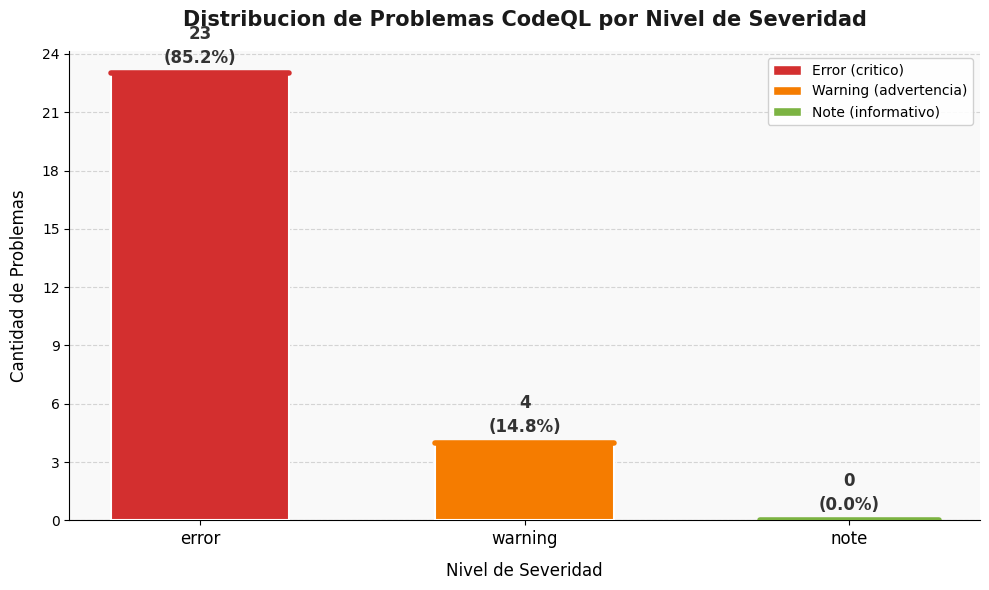

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

if not df_codeql.empty:
    level_counts = (
        df_codeql["level"]
        .value_counts()
        .reindex(["error", "warning", "note"], fill_value=0)
    )
    total = level_counts.sum()

    colores = {"error": "#d32f2f", "warning": "#f57c00", "note": "#7cb342"}
    color_list = [colores[n] for n in level_counts.index]

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.bar(
        range(len(level_counts)),
        level_counts.values,
        color=color_list,
        edgecolor="white",
        linewidth=1.5,
        width=0.55,
        zorder=3,
    )

    for bar, val in zip(bars, level_counts.values):
        pct = val / total * 100 if total > 0 else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(level_counts.values) * 0.015,
            # --- AQUÍ ESTÁ LA CORRECCIÓN ---
            f"{val:,}\n({pct:.1f}%)",
            ha="center", va="bottom",
            fontsize=12, fontweight="bold", color="#333333",
            linespacing=1.4,
        )

    for bar, nivel in zip(bars, level_counts.index):
        ax.plot(
            [bar.get_x(), bar.get_x() + bar.get_width()],
            [bar.get_height(), bar.get_height()],
            color=colores[nivel], linewidth=4, solid_capstyle="round", zorder=4
        )

    ax.set_facecolor("#f9f9f9")
    fig.patch.set_facecolor("white")
    ax.set_title(
        "Distribucion de Problemas CodeQL por Nivel de Severidad",
        fontsize=15, fontweight="bold", pad=18, color="#1a1a1a"
    )
    ax.set_xlabel("Nivel de Severidad", fontsize=12, labelpad=10)
    ax.set_ylabel("Cantidad de Problemas", fontsize=12, labelpad=10)
    ax.set_xticks(range(len(level_counts)))
    ax.set_xticklabels(level_counts.index, fontsize=12, rotation=0)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    from matplotlib.patches import Patch
    leyendas = {
        "error": "Error (critico)", "warning": "Warning (advertencia)", "note": "Note (informativo)"}
    handles = [Patch(facecolor=colores[n], edgecolor="white",
                     label=leyendas[n]) for n in colores]
    ax.legend(handles=handles, fontsize=10, loc="upper right",
              framealpha=0.9, edgecolor="#cccccc")

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos CodeQL para graficar.")

### 3.2 Problemas por repositorio (CodeQL)


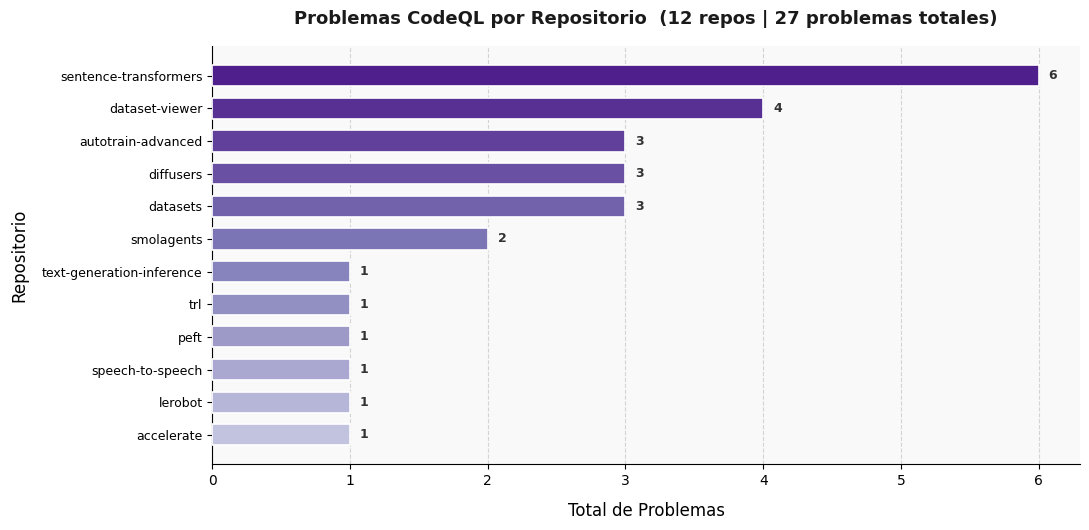

In [4]:
if not df_codeql.empty:
    issues_por_repo = df_codeql["repo"].value_counts(
    ).sort_values(ascending=True)
    total_repos = len(issues_por_repo)

    colores_gradiente = plt.cm.Purples(np.linspace(0.35, 0.9, total_repos))

    fig, ax = plt.subplots(figsize=(11, max(5, total_repos * 0.45)))

    bars = ax.barh(
        issues_por_repo.index,
        issues_por_repo.values,
        color=colores_gradiente,
        edgecolor="white",
        linewidth=1.2,
        height=0.65,
        zorder=3,
    )

    # Etiqueta con el valor al final de cada barra
    for bar, val in zip(bars, issues_por_repo.values):
        ax.text(
            bar.get_width() + max(issues_por_repo.values) * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}",
            va="center", ha="left",
            fontsize=9, fontweight="bold", color="#333333",
        )

    # Estilo
    ax.set_facecolor("#f9f9f9")
    fig.patch.set_facecolor("white")
    ax.set_title(
        "Problemas CodeQL por Repositorio",
        fontsize=15, fontweight="bold", pad=16, color="#1a1a1a"
    )
    ax.set_xlabel("Total de Problemas", fontsize=12, labelpad=10)
    ax.set_ylabel("Repositorio", fontsize=12, labelpad=10)
    ax.tick_params(axis="y", labelsize=9)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="x", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # Anotacion del total
    ax.set_title(
        f"Problemas CodeQL por Repositorio  ({total_repos} repos | {issues_por_repo.sum():,} problemas totales)",
        fontsize=13, fontweight="bold", pad=16, color="#1a1a1a"
    )

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos CodeQL para graficar.")

### 3.3 Reglas de CodeQL más frecuentes (Top 10)


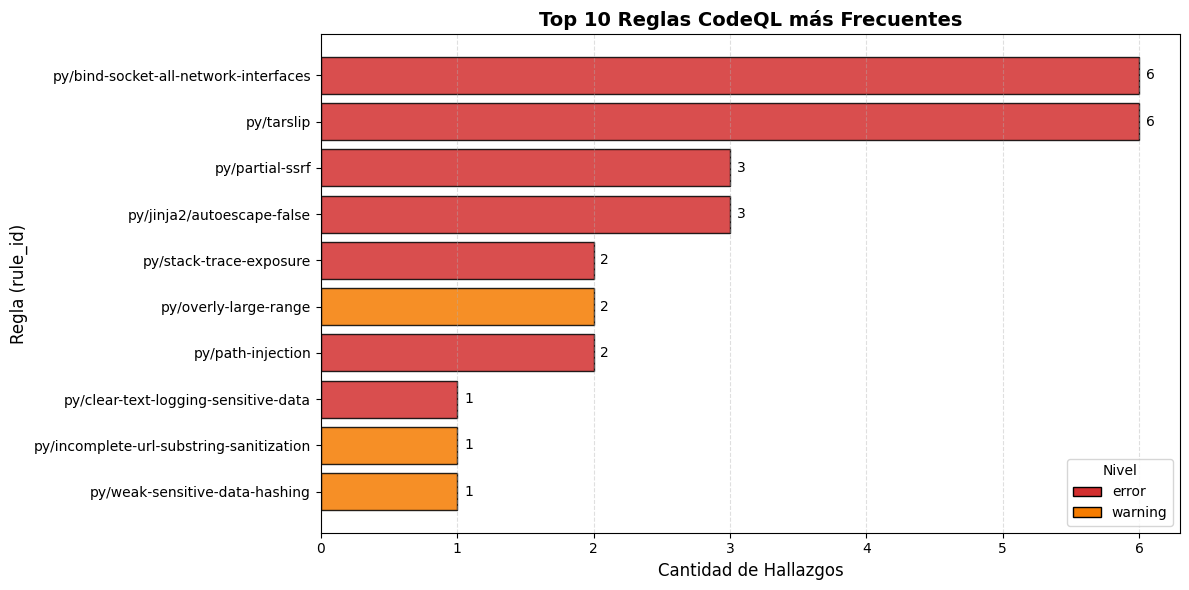


Detalle:
                                 rule_id   level  count
   py/bind-socket-all-network-interfaces   error      6
                              py/tarslip   error      6
                         py/partial-ssrf   error      3
              py/jinja2/autoescape-false   error      3
                 py/stack-trace-exposure   error      2
                   py/overly-large-range warning      2
                       py/path-injection   error      2
    py/clear-text-logging-sensitive-data   error      1
py/incomplete-url-substring-sanitization warning      1
          py/weak-sensitive-data-hashing warning      1


In [5]:
if not df_codeql.empty:
    top_rules = (
        df_codeql.groupby(["rule_id", "level"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(10)
    )

    colores = {
        "error": "#d32f2f",
        "warning": "#f57c00",
        "note": "#7cb342",
    }
    color_list = [colores.get(lvl, "#757575") for lvl in top_rules["level"]]

    # Invertir para que el más frecuente quede arriba
    top_rules_plot = top_rules.iloc[::-1]
    color_list_rev = color_list[::-1]

    fig, ax = plt.subplots(figsize=(12, 6))

    bars = ax.barh(
        top_rules_plot["rule_id"],
        top_rules_plot["count"],
        color=color_list_rev,
        edgecolor="black",
        alpha=0.85,
    )

    for bar, val in zip(bars, top_rules_plot["count"]):
        ax.text(
            bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            str(val),
            va="center",
            fontsize=10,
        )

    ax.set_title(
        "Top 10 Reglas CodeQL más Frecuentes",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Cantidad de Hallazgos", fontsize=12)
    ax.set_ylabel("Regla (rule_id)", fontsize=12)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    # Leyenda de niveles presentes
    from matplotlib.patches import Patch
    niveles_presentes = top_rules["level"].unique()
    handles = [
        Patch(facecolor=colores.get(n, "#757575"), edgecolor="black", label=n)
        for n in ["error", "warning", "note"]
        if n in niveles_presentes
    ]
    if handles:
        ax.legend(handles=handles, title="Nivel", loc="lower right")

    plt.tight_layout()
    plt.show()

    print("\nDetalle:")
    print(top_rules.to_string(index=False))
else:
    print("No hay datos CodeQL para graficar.")

### 3.4 Archivos más afectados (Top 10)


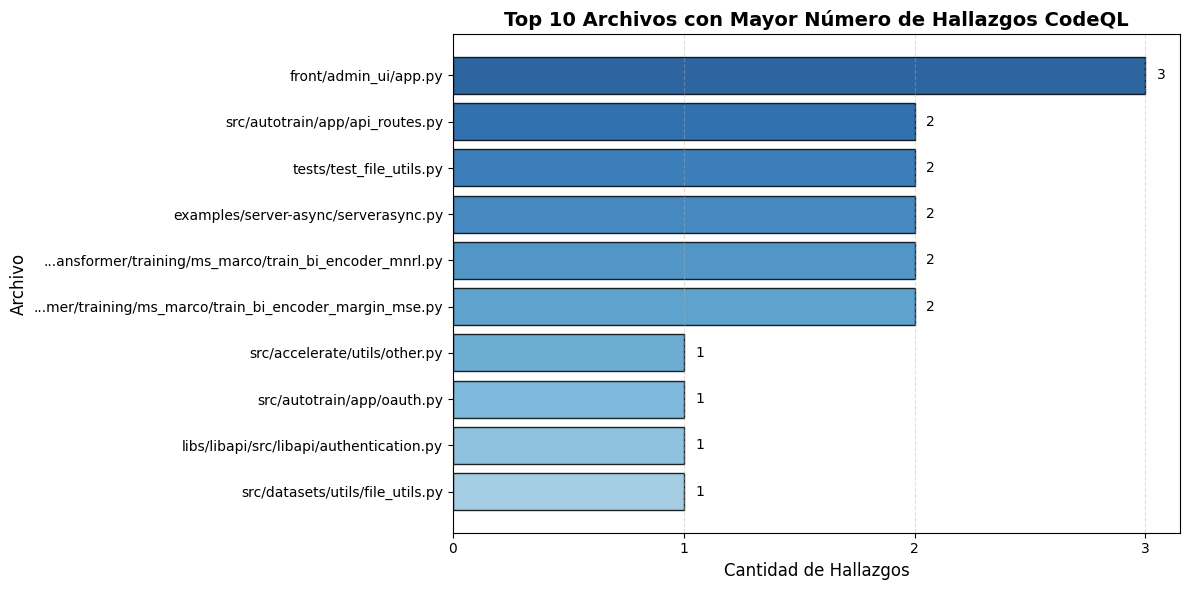

In [6]:
if not df_codeql.empty:
    top_files = df_codeql["file"].value_counts().head(10)

    # Acortar rutas muy largas para mejorar legibilidad
    labels = [
        f if len(f) <= 55 else "..." + f[-52:]
        for f in top_files.index
    ]

    colores_grad = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_files)))

    fig, ax = plt.subplots(figsize=(12, 6))

    bars = ax.barh(
        labels[::-1],
        top_files.values[::-1],
        color=colores_grad,
        edgecolor="black",
        alpha=0.85,
    )

    for bar, val in zip(bars, top_files.values[::-1]):
        ax.text(
            bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            str(val),
            va="center",
            fontsize=10,
        )

    ax.set_title(
        "Top 10 Archivos con Mayor Número de Hallazgos CodeQL",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Cantidad de Hallazgos", fontsize=12)
    ax.set_ylabel("Archivo", fontsize=12)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos CodeQL para graficar.")

---

## 4. Carga de datos — Grype (SCA)

Grype detecta vulnerabilidades conocidas en las dependencias del proyecto. Cada hallazgo incluye:

- `package_name`: nombre del paquete afectado
- `current_version`: versión instalada
- `fix_version`: versión que corrige la vulnerabilidad
- `vuln_id`: identificador CVE / GHSA
- `cvss_score`: puntuación CVSS (0–10)
- `vuln_severity`: nivel de severidad (`Critical` / `High` / `Medium` / `Low`)
- `message`: descripción de la vulnerabilidad


In [7]:
all_vulns = []

for grype_file in grype_files:
    repo_name = grype_file.stem.replace("-grype", "")

    with open(grype_file, encoding="utf-8") as f:
        data = json.load(f)

    for match in data.get("matches", []):
        vuln = match.get("vulnerability", {})
        artifact = match.get("artifact", {})
        fix = vuln.get("fix", {})

        # Extraer CVSS score del primer registro disponible
        cvss_list = vuln.get("cvss", [])
        cvss_score = None
        for cvss in cvss_list:
            score = cvss.get("metrics", {}).get("baseScore")
            if score is not None:
                cvss_score = score
                break

        fix_versions = fix.get("versions", [])
        fix_version = fix_versions[0] if fix_versions else "N/A"

        all_vulns.append({
            "repo": repo_name,
            "vuln_id": vuln.get("id", "N/A"),
            "package_name": artifact.get("name", "N/A"),
            "current_version": artifact.get("version", "N/A"),
            "fix_version": fix_version,
            "vuln_severity": vuln.get("severity", "Unknown"),
            "cvss_score": cvss_score,
            "message": vuln.get("description", "N/A")[:200],
        })

df_vulns = pd.DataFrame(all_vulns)

if df_vulns.empty:
    print("No se encontraron vulnerabilidades Grype.")
else:
    print(f"Total de vulnerabilidades : {len(df_vulns)}")
    print(f"Repositorios analizados   : {df_vulns['repo'].nunique()}")
    print(f"Paquetes únicos afectados : {df_vulns['package_name'].nunique()}")
    print(f"CVEs/GHSAs únicos         : {df_vulns['vuln_id'].nunique()}")
    print()
    print("Distribución por severidad:")
    print(df_vulns["vuln_severity"].value_counts().to_string())
    print()
    print(df_vulns[["repo", "vuln_id", "package_name", "current_version",
          "vuln_severity", "cvss_score"]].head(5).to_string())

Total de vulnerabilidades : 1358
Repositorios analizados   : 13
Paquetes únicos afectados : 58
CVEs/GHSAs únicos         : 196

Distribución por severidad:
vuln_severity
Medium      625
High        381
Low         341
Critical     11

                 repo              vuln_id              package_name                           current_version vuln_severity  cvss_score
0          accelerate  GHSA-mrrh-fwg8-r2c3  tj-actions/changed-files  3f54ebb830831fc121d3263c1857cfbdc310cdb9          High         8.6
1          accelerate  GHSA-mcph-m25j-8j63  tj-actions/changed-files  3f54ebb830831fc121d3263c1857cfbdc310cdb9          High         7.3
2  autotrain-advanced  GHSA-7p94-766c-hgjp                      nltk                                     3.9.1      Critical        10.0
3  autotrain-advanced  GHSA-wp53-j4wj-2cfg          python-multipart                                    0.0.20          High         8.6
4  autotrain-advanced  GHSA-pq5p-34cr-23v9                   authlib            

---

## 5. Analisis Grype


### 5.1 Distribución de vulnerabilidades Grype por severidad CVSS


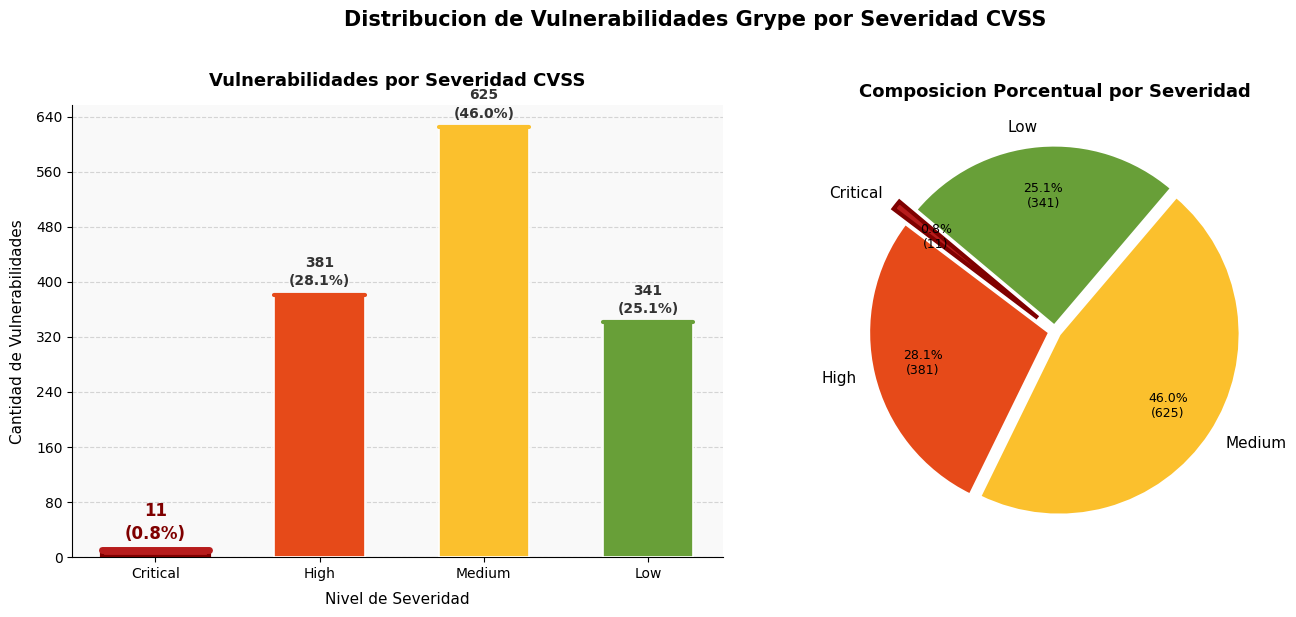

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

if not df_vulns.empty:
    sev_order = ["Critical", "High", "Medium", "Low", "Negligible"]
    sev_counts = (
        df_vulns["vuln_severity"]
        .value_counts()
        .reindex([s for s in sev_order if s in df_vulns["vuln_severity"].unique()], fill_value=0)
    )
    total = sev_counts.sum()

    colores = {
        "Critical":   "#b71c1c",
        "High":       "#e64a19",
        "Medium":     "#fbc02d",
        "Low":        "#689f38",
        "Negligible": "#90a4ae",
    }
    color_list = [colores.get(n, "#757575") for n in sev_counts.index]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor("white")

    # --- Grafico de barras ---
    ax = axes[0]
    ax.set_facecolor("#f9f9f9")

    for i, (nivel, val, color) in enumerate(zip(sev_counts.index, sev_counts.values, color_list)):
        es_critical = nivel == "Critical"
        bar = ax.bar(
            i, val,
            color=color,
            edgecolor="#7f0000" if es_critical else "white",
            linewidth=3 if es_critical else 1.2,
            width=0.65 if es_critical else 0.55,
            zorder=3,
        )
        pct = val / total * 100 if total > 0 else 0

        # --- CORRECCIÓN 1 ---
        ax.text(
            i, val + max(sev_counts.values) * 0.015,
            f"{val:,}\n({pct:.1f}%)",
            ha="center", va="bottom",
            fontsize=12 if es_critical else 10,
            fontweight="bold",
            color="#7f0000" if es_critical else "#333333",
            linespacing=1.4,
        )

        # Linea de acento en el tope
        ax.plot(
            [i - (0.325 if es_critical else 0.275), i +
             (0.325 if es_critical else 0.275)],
            [val, val],
            color=color, linewidth=5 if es_critical else 3,
            solid_capstyle="round", zorder=4
        )

    ax.set_title("Vulnerabilidades por Severidad CVSS",
                 fontsize=13, fontweight="bold", pad=14)
    ax.set_xlabel("Nivel de Severidad", fontsize=11, labelpad=8)
    ax.set_ylabel("Cantidad de Vulnerabilidades", fontsize=11, labelpad=8)
    ax.set_xticks(range(len(sev_counts)))
    ax.set_xticklabels(sev_counts.index, fontsize=10, rotation=0)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # --- Grafico de pastel ---
    ax2 = axes[1]
    ax2.set_facecolor("#f9f9f9")

    explode = [0.12 if n == "Critical" else 0.03 for n in sev_counts.index]

    def fmt_pct(p):
        # --- CORRECCIÓN 2 ---
        return "{:.1f}%\n({})".format(p, int(round(p * total / 100)))

    wedges, texts, autotexts = ax2.pie(
        sev_counts.values,
        labels=sev_counts.index,
        autopct=fmt_pct,
        colors=color_list,
        startangle=140,
        pctdistance=0.72,
        explode=explode,
        wedgeprops=dict(edgecolor="white", linewidth=2),
    )
    # Critical: borde mas grueso en el pie
    for wedge, nivel in zip(wedges, sev_counts.index):
        if nivel == "Critical":
            wedge.set_edgecolor("#7f0000")
            wedge.set_linewidth(3)
    for text in texts:
        text.set_fontsize(11)
    for autotext in autotexts:
        autotext.set_fontsize(9)
    ax2.set_title("Composicion Porcentual por Severidad",
                  fontsize=13, fontweight="bold")

    plt.suptitle(
        "Distribucion de Vulnerabilidades Grype por Severidad CVSS",
        fontsize=15, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos Grype para graficar.")

### 5.2 Vulnerabilidades por repositorio


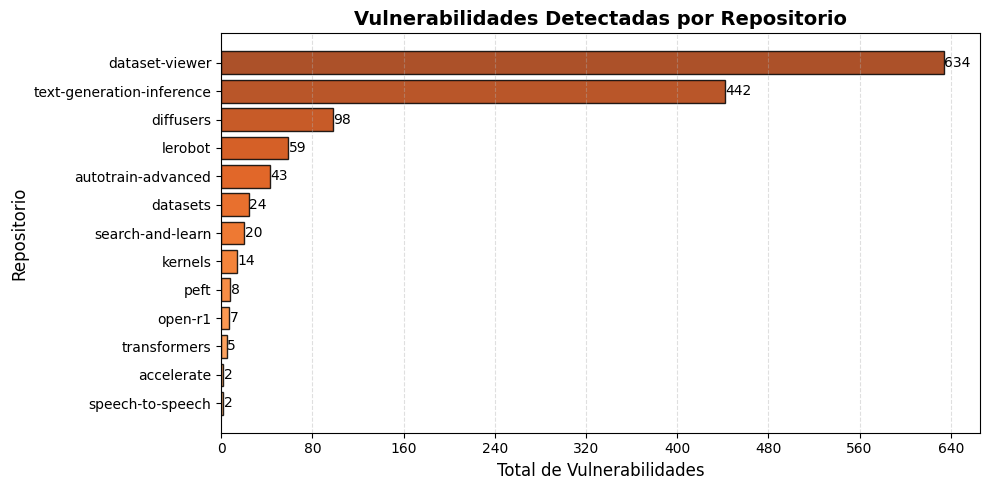

In [9]:
if not df_vulns.empty:
    vulns_por_repo = df_vulns["repo"].value_counts(
    ).sort_values(ascending=True)

    colores_grad = plt.cm.Oranges(np.linspace(0.4, 0.9, len(vulns_por_repo)))

    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.barh(
        vulns_por_repo.index,
        vulns_por_repo.values,
        color=colores_grad,
        edgecolor="black",
        alpha=0.85,
    )

    for bar, val in zip(bars, vulns_por_repo.values):
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            str(val),
            va="center",
            fontsize=10,
        )

    ax.set_title(
        "Vulnerabilidades Detectadas por Repositorio",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Total de Vulnerabilidades", fontsize=12)
    ax.set_ylabel("Repositorio", fontsize=12)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos Grype para graficar.")

### 5.3 Paquetes más vulnerables (Top 10)


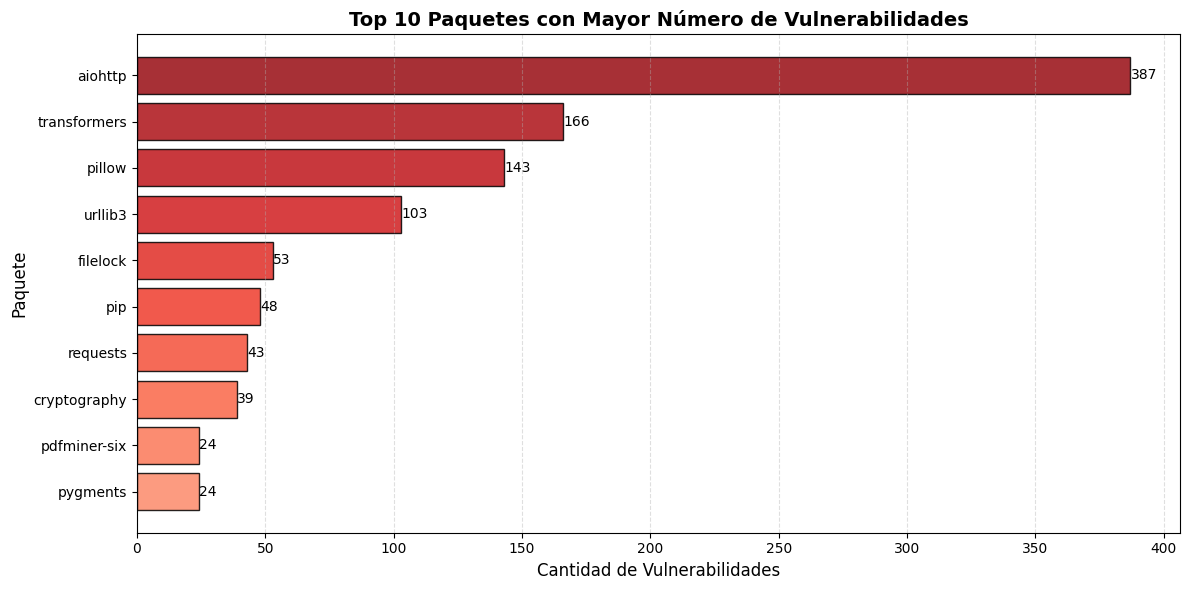


Detalle — Top 10 paquetes más vulnerables:
              total  cvss_max  cvss_medio
package_name                             
aiohttp         387       9.1        4.98
transformers    166       9.0        5.55
pillow          143       8.6        6.82
urllib3         103       8.9        7.76
filelock         53       6.3        5.79
pip              48       5.9        4.45
requests         43       5.3        4.67
cryptography     39       8.2        6.75
torch            24       9.3        4.16
pygments         24       3.3        3.30


In [10]:
if not df_vulns.empty:
    top_packages = df_vulns["package_name"].value_counts().head(
        10).sort_values(ascending=True)

    colores_grad = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_packages)))

    fig, ax = plt.subplots(figsize=(12, 6))

    bars = ax.barh(
        top_packages.index,
        top_packages.values,
        color=colores_grad,
        edgecolor="black",
        alpha=0.85,
    )

    for bar, val in zip(bars, top_packages.values):
        ax.text(
            bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            str(val),
            va="center",
            fontsize=10,
        )

    ax.set_title(
        "Top 10 Paquetes con Mayor Número de Vulnerabilidades",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Cantidad de Vulnerabilidades", fontsize=12)
    ax.set_ylabel("Paquete", fontsize=12)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

    print("\nDetalle — Top 10 paquetes más vulnerables:")
    print(
        df_vulns.groupby("package_name")
        .agg(
            total=("vuln_id", "count"),
            cvss_max=("cvss_score", "max"),
            cvss_medio=("cvss_score", "mean"),
        )
        .sort_values("total", ascending=False)
        .head(10)
        .round(2)
        .to_string()
    )
else:
    print("No hay datos Grype para graficar.")

### 5.4 Disponibilidad de parches (fix_version)


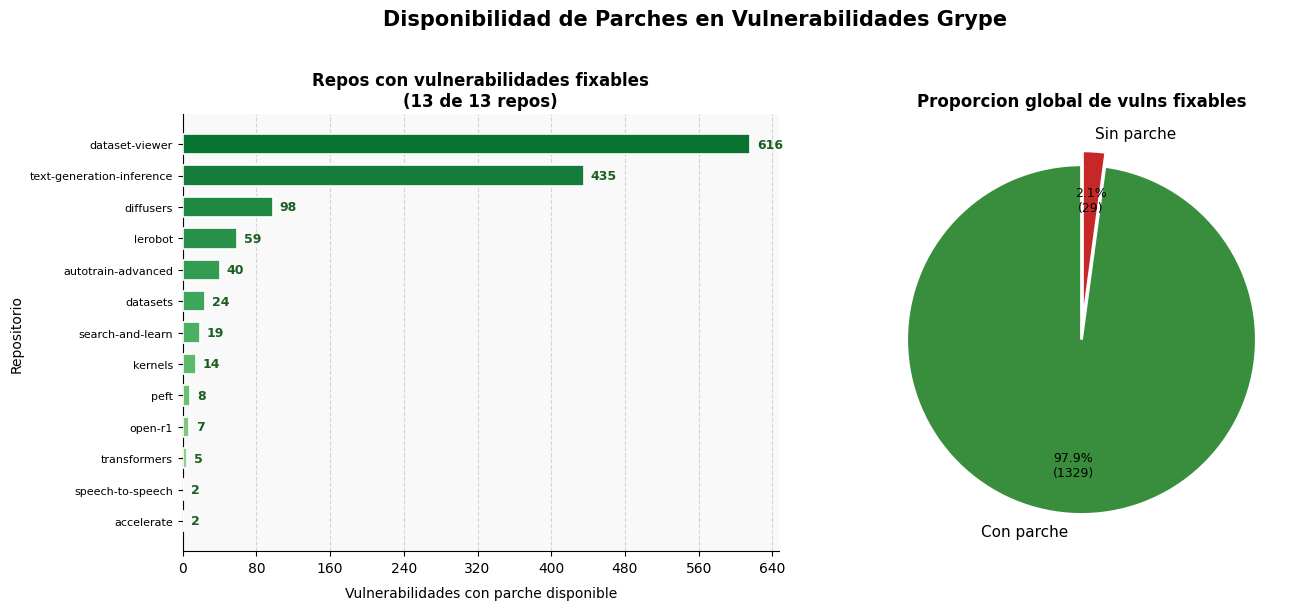

Total vulnerabilidades : 1,358
  Con parche disponible: 1,329  (97.9%)
  Sin parche disponible: 29  (2.1%)
Repos que deben actualizar dependencias: 13


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

if not df_vulns.empty:
    df_fix = df_vulns.copy()
    df_fix["tiene_fix"] = df_fix["fix_version"].apply(
        lambda v: "Con parche" if pd.notna(v) and str(v).strip() not in (
            "", "N/A", "none", "None") else "Sin parche"
    )

    # --- Datos globales para el pie ---
    fix_global = df_fix["tiene_fix"].value_counts().reindex(
        ["Con parche", "Sin parche"], fill_value=0)

    # --- Repos con al menos una vulnerabilidad fixable ---
    repos_fix = (
        df_fix[df_fix["tiene_fix"] == "Con parche"]
        .groupby("repo")["vuln_id"]
        .count()
        .sort_values(ascending=True)
    )

    colores_fix = {"Con parche": "#388e3c", "Sin parche": "#c62828"}
    colores_grad = plt.cm.Greens(np.linspace(0.35, 0.85, len(repos_fix)))

    fig, axes = plt.subplots(1, 2, figsize=(
        14, max(5, len(repos_fix) * 0.38 + 1)))

    # --- Barras horizontales: repos con vulns fixables ---
    ax = axes[0]
    if len(repos_fix) > 0:
        bars = ax.barh(
            repos_fix.index,
            repos_fix.values,
            color=colores_grad,
            edgecolor="white",
            linewidth=1.2,
            height=0.65,
            zorder=3,
        )
        for bar, val in zip(bars, repos_fix.values):
            ax.text(
                bar.get_width() + max(repos_fix.values) * 0.012,
                bar.get_y() + bar.get_height() / 2,
                f"{val:,}",
                va="center", ha="left",
                fontsize=9, fontweight="bold", color="#1b5e20",
            )
    else:
        # CORRECCIÓN 1: Todo en la misma línea con \n
        ax.text(0.5, 0.5, "Ningún repositorio\ntiene parche disponible",
                ha="center", va="center", transform=ax.transAxes, fontsize=11, color="gray")

    ax.set_facecolor("#f9f9f9")

    # CORRECCIÓN 2: Todo en la misma línea con \n
    ax.set_title(
        f"Repos con vulnerabilidades fixables\n({len(repos_fix)} de {df_fix['repo'].nunique()} repos)",
        fontsize=12, fontweight="bold"
    )
    ax.set_xlabel("Vulnerabilidades con parche disponible",
                  fontsize=10, labelpad=8)
    ax.set_ylabel("Repositorio", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="x", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # --- Pastel: proporcion global Con / Sin parche ---
    ax2 = axes[1]
    total_fix = fix_global.sum()

    def fmt_pct(p):
        # CORRECCIÓN 3: Todo en la misma línea con \n
        return "{:.1f}%\n({})".format(p, int(round(p * total_fix / 100)))

    wedges, texts, autotexts = ax2.pie(
        fix_global.values,
        labels=fix_global.index,
        autopct=fmt_pct,
        colors=[colores_fix[k] for k in fix_global.index],
        startangle=90,
        pctdistance=0.72,
        wedgeprops=dict(edgecolor="white", linewidth=2),
        explode=[0.04] * len(fix_global),
    )
    for text in texts:
        text.set_fontsize(11)
    for autotext in autotexts:
        autotext.set_fontsize(9)
    ax2.set_facecolor("#f9f9f9")
    ax2.set_title("Proporcion global de vulns fixables",
                  fontsize=12, fontweight="bold")

    plt.suptitle(
        "Disponibilidad de Parches en Vulnerabilidades Grype",
        fontsize=15, fontweight="bold", y=1.02,
    )
    fig.patch.set_facecolor("white")
    plt.tight_layout()
    plt.show()

    # Resumen textual
    con = fix_global.get("Con parche", 0)
    sin = fix_global.get("Sin parche", 0)
    pct_con = con / total_fix * 100 if total_fix > 0 else 0
    print(f"Total vulnerabilidades : {total_fix:,}")
    print(f"  Con parche disponible: {con:,}  ({pct_con:.1f}%)")
    print(f"  Sin parche disponible: {sin:,}  ({100-pct_con:.1f}%)")
    print(f"Repos que deben actualizar dependencias: {len(repos_fix)}")
else:
    print("No hay datos Grype para graficar.")

---

## 6. Filtrado y resumen ejecutivo

### 6.1 Filtrado de datos prioritarios

Se aplican los siguientes filtros para el análisis de prioridades:

| Fuente | Filtro aplicado | Justificación |
|--------|-----------------|---------------|
| **CodeQL** | Solo `level == "error"` | Vulnerabilidades de seguridad confirmadas |
| **Grype** | Solo `vuln_severity` en `["Critical", "High"]` | CVEs con CVSS alto que requieren acción inmediata |


In [12]:
# ── Filtrado CodeQL: solo errores ─────────────────────────────────────────
if not df_codeql.empty:
    df_codeql_filtered = df_codeql[df_codeql["level"] == "error"].copy()
else:
    df_codeql_filtered = pd.DataFrame()

# ── Filtrado Grype: solo Critical y High ─────────────────────────────────
if not df_vulns.empty:
    df_vulns_filtered = df_vulns[
        df_vulns["vuln_severity"].isin(["Critical", "High"])
    ].copy()
else:
    df_vulns_filtered = pd.DataFrame()

print("Resultado del filtrado:")
print(
    f"  CodeQL total         : {len(df_codeql):>5}  →  tras filtro (error)           : {len(df_codeql_filtered):>5}")
print(
    f"  Grype total          : {len(df_vulns):>5}  →  tras filtro (Critical + High) : {len(df_vulns_filtered):>5}")
print()

if not df_codeql_filtered.empty:
    print("CodeQL errores — por repositorio:")
    print(df_codeql_filtered["repo"].value_counts().to_string())

if not df_vulns_filtered.empty:
    print("\nGrype Critical/High — por repositorio:")
    print(df_vulns_filtered["repo"].value_counts().to_string())
    print("\nGrype Critical/High — por severidad:")
    print(df_vulns_filtered["vuln_severity"].value_counts().to_string())

Resultado del filtrado:
  CodeQL total         :    27  →  tras filtro (error)           :    23
  Grype total          :  1358  →  tras filtro (Critical + High) :   392

CodeQL errores — por repositorio:
repo
sentence-transformers        6
dataset-viewer               4
diffusers                    3
autotrain-advanced           2
smolagents                   2
accelerate                   1
lerobot                      1
peft                         1
speech-to-speech             1
text-generation-inference    1
trl                          1

Grype Critical/High — por repositorio:
repo
dataset-viewer               185
text-generation-inference    112
lerobot                       24
diffusers                     20
autotrain-advanced            17
search-and-learn              11
datasets                       9
kernels                        7
transformers                   4
accelerate                     2
speech-to-speech               1

Grype Critical/High — por severidad:
vul

### 6.2 Visualización comparada de datos filtrados


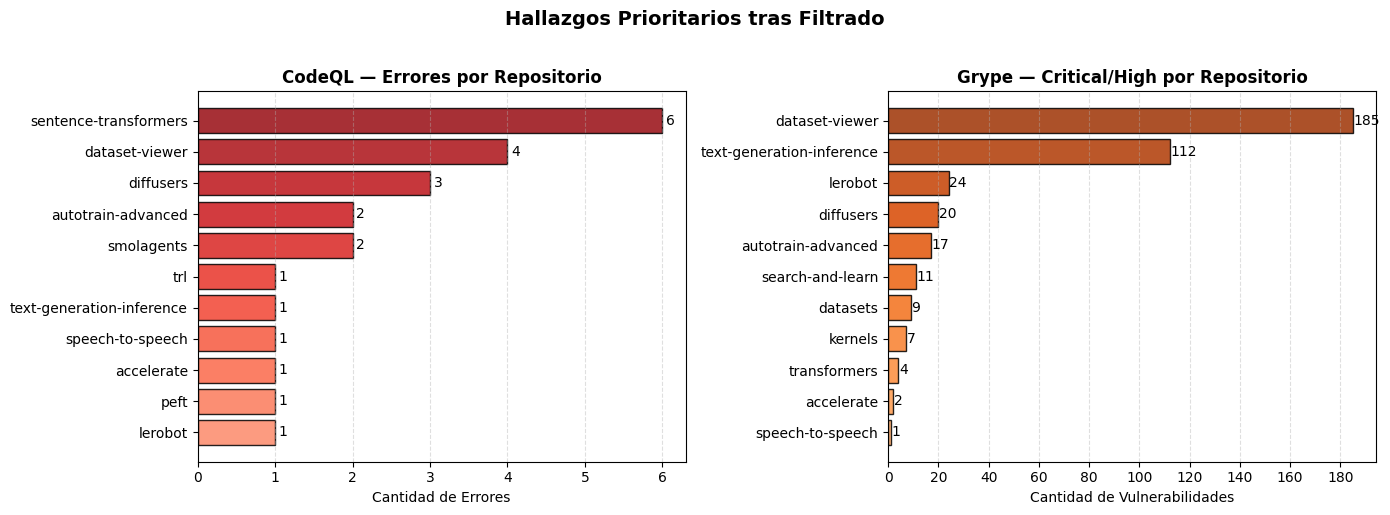

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- CodeQL errores por repositorio ---
ax = axes[0]
if not df_codeql_filtered.empty:
    datos = df_codeql_filtered["repo"].value_counts(
    ).sort_values(ascending=True)
    colores_c = plt.cm.Reds(np.linspace(0.4, 0.9, len(datos)))
    bars = ax.barh(datos.index, datos.values, color=colores_c,
                   edgecolor="black", alpha=0.85)
    for bar, val in zip(bars, datos.values):
        ax.text(bar.get_width() + 0.05, bar.get_y() +
                bar.get_height() / 2, str(val), va="center", fontsize=10)
    ax.set_title("CodeQL — Errores por Repositorio",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Cantidad de Errores", fontsize=10)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="x", linestyle="--", alpha=0.4)
else:
    ax.text(0.5, 0.5, "Sin hallazgos de nivel error",
            ha="center", va="center", transform=ax.transAxes)
    ax.set_title("CodeQL — Errores por Repositorio",
                 fontsize=12, fontweight="bold")

# --- Grype Critical/High por repositorio ---
ax2 = axes[1]
if not df_vulns_filtered.empty:
    datos2 = df_vulns_filtered["repo"].value_counts(
    ).sort_values(ascending=True)
    colores_g = plt.cm.Oranges(np.linspace(0.4, 0.9, len(datos2)))
    bars2 = ax2.barh(datos2.index, datos2.values,
                     color=colores_g, edgecolor="black", alpha=0.85)
    for bar, val in zip(bars2, datos2.values):
        ax2.text(bar.get_width() + 0.3, bar.get_y() +
                 bar.get_height() / 2, str(val), va="center", fontsize=10)
    ax2.set_title("Grype — Critical/High por Repositorio",
                  fontsize=12, fontweight="bold")
    ax2.set_xlabel("Cantidad de Vulnerabilidades", fontsize=10)
    ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax2.grid(axis="x", linestyle="--", alpha=0.4)
else:
    ax2.text(0.5, 0.5, "Sin vulnerabilidades Critical o High",
             ha="center", va="center", transform=ax2.transAxes)
    ax2.set_title("Grype — Critical/High por Repositorio",
                  fontsize=12, fontweight="bold")

plt.suptitle(
    "Hallazgos Prioritarios tras Filtrado",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

### 6.3 Resumen ejecutivo


In [14]:
print("=" * 60)
print("       RESUMEN EJECUTIVO — ANÁLISIS DE SEGURIDAD")
print("=" * 60)
print(f"  Fecha del análisis : {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"  Herramientas       : CodeQL (SAST) + Grype (SCA)")
print()

# ── Sección CodeQL ────────────────────────────────────────────────────────
print("  ─── CODEQL (SAST) ────────────────────────────────")
if not df_codeql.empty:
    level_totals = df_codeql["level"].value_counts()
    print(f"  Total hallazgos                : {len(df_codeql)}")
    print(f"  Errores (críticos)             : {level_totals.get('error', 0)}")
    print(
        f"  Advertencias                   : {level_totals.get('warning', 0)}")
    print(f"  Notas                          : {level_totals.get('note', 0)}")
    print(
        f"  Reglas únicas disparadas       : {df_codeql['rule_id'].nunique()}")
    print(f"  Archivos afectados             : {df_codeql['file'].nunique()}")
    print(f"  Hallazgos prioritarios (error) : {len(df_codeql_filtered)}")
else:
    print("  Sin datos disponibles.")

print()

# ── Sección Grype ─────────────────────────────────────────────────────────
print("  ─── GRYPE (SCA) ──────────────────────────────────")
if not df_vulns.empty:
    sev_totals = df_vulns["vuln_severity"].value_counts()
    cvss_val = df_vulns["cvss_score"].dropna()
    print(f"  Total vulnerabilidades         : {len(df_vulns)}")
    print(
        f"  Critical                       : {sev_totals.get('Critical', 0)}")
    print(f"  High                           : {sev_totals.get('High', 0)}")
    print(f"  Medium                         : {sev_totals.get('Medium', 0)}")
    print(f"  Low                            : {sev_totals.get('Low', 0)}")
    print(
        f"  Paquetes únicos afectados      : {df_vulns['package_name'].nunique()}")
    print(
        f"  CVEs/GHSAs únicos              : {df_vulns['vuln_id'].nunique()}")
    if not cvss_val.empty:
        print(f"  CVSS medio                     : {cvss_val.mean():.2f}")
        print(f"  CVSS máximo                    : {cvss_val.max():.1f}")
    print(f"  Prioritarios (Critical+High)   : {len(df_vulns_filtered)}")
else:
    print("  Sin datos disponibles.")

print()
print("=" * 60)

       RESUMEN EJECUTIVO — ANÁLISIS DE SEGURIDAD
  Fecha del análisis : 2026-05-08 06:52
  Herramientas       : CodeQL (SAST) + Grype (SCA)

  ─── CODEQL (SAST) ────────────────────────────────
  Total hallazgos                : 27
  Errores (críticos)             : 23
  Advertencias                   : 4
  Notas                          : 0
  Reglas únicas disparadas       : 10
  Archivos afectados             : 20
  Hallazgos prioritarios (error) : 23

  ─── GRYPE (SCA) ──────────────────────────────────
  Total vulnerabilidades         : 1358
  Critical                       : 11
  High                           : 381
  Medium                         : 625
  Low                            : 341
  Paquetes únicos afectados      : 58
  CVEs/GHSAs únicos              : 196
  CVSS medio                     : 5.83
  CVSS máximo                    : 10.0
  Prioritarios (Critical+High)   : 392



---

## Conclusiones

### Contextualizacion

Hugging Face es la plataforma de referencia para el desarrollo y distribucion de modelos de lenguaje,
datasets y herramientas de ML de codigo abierto. Su Hub concentra mas de un millon de modelos y es
utilizado diariamente por investigadores y empresas de todo el mundo. Desde el punto de vista de la
seguridad, esto representa un escenario de alto impacto: el codigo de Hugging Face se ejecuta en
entornos cloud, pipelines de datos y sistemas de inferencia a escala global, por lo que cualquier
vulnerabilidad en sus dependencias puede comprometer indirectamente a miles de proyectos que dependen
de su ecosistema.

Es por esto que el analisis realizado busca identificar vulnerabilidades en los componentes y el codigo
fuente de la organizacion. Para esto se ejecutaron los SBOMs con Syft, analisis estatico del codigo
fuente con CodeQL, y analisis de vulnerabilidades en dependencias con Grype sobre los repositorios
de libre acceso de la organizacion huggingface en GitHub.

---

### Resultados cuantitativos

Los resultados obtenidos del analisis de **24 repositorios con CodeQL** y **26 repositorios con Grype** se componen de:

- **Hallazgos CodeQL (SAST):** 27 problemas detectados en el codigo fuente de 12 repositorios,
distribuidos en 23 errores (85.2%) y 4 advertencias (14.8%). Se dispararon 10 reglas unicas distintas
sobre 20 archivos afectados. Los errores representan vulnerabilidades criticas que requieren
refactorizacion manual del codigo fuente y no pueden resolverse con una simple actualizacion de paquete.
- **Vulnerabilidades Grype (SCA):** 1.358 CVEs/GHSAs detectados en dependencias de terceros de 13
repositorios, afectando a 58 paquetes unicos con 196 identificadores de vulnerabilidad distintos.
La distribucion por severidad CVSS es: 11 Critical (0.8%), 381 High (28.1%), 625 Medium (46.0%) y
341 Low (25.1%), con un CVSS medio de 5.83 y un maximo de 10.0. El **97.9%** (1.329 de 1.358) de estas
vulnerabilidades cuenta con una version corregida disponible, y los 13 repositorios analizados tienen
al menos una dependencia parcheable.
- **Repositorios mas afectados:** `dataset-viewer` concentra la mayor cantidad de vulnerabilidades Grype
(634 CVEs, incluyendo 185 de nivel Critical/High), seguido de `text-generation-inference` con 442
vulnerabilidades totales (112 Critical/High). En CodeQL, `sentence-transformers` lidera con 6 errores.

---

### Patrones identificados

El analisis revela patrones estructurales que van mas alla de los hallazgos individuales:

**1. Patron sistémico de codigo inseguro — `py/bind-socket-all-network-interfaces` en 6 repositorios**

Esta es la regla CodeQL mas extendida en la organizacion. Significa que multiples equipos de desarrollo
han escrito codigo que enlaza sockets a todas las interfaces de red (0.0.0.0), exponiendo servicios
innecesariamente. No es un error aislado: es un patron de desarrollo repetido transversalmente que
sugiere ausencia de guias de codificacion segura a nivel organizacional.

**2. Dependencias transversales sin governance — `aiohttp` y `transformers`**

El paquete `aiohttp` concentra 387 vulnerabilidades y aparece en 4 repositorios con versiones
distintas (3.11.12 en `text-generation-inference`, 3.12.14 en `diffusers`, 3.12.15 en `dataset-viewer`,
3.13.3 en `lerobot`). La falta de una version coordinada indica que no existe un proceso centralizado
de gestion de dependencias comunes. Del mismo modo, `transformers` aparece en 6 repositorios con
los mismos 5 CVEs sin corregir: una sola actualizacion coordinada de ese paquete eliminaria cientos
de hallazgos simultaneamente.

**3. Doble exposicion en 7 repositorios**

Los repositorios `dataset-viewer`, `text-generation-inference`, `diffusers`, `lerobot`,
`autotrain-advanced`, `accelerate` y `speech-to-speech` presentan simultaneamente errores de CodeQL
y vulnerabilidades Critical/High de Grype. Esto significa que tienen problemas tanto en su codigo
fuente propio como en sus dependencias — requieren atencion en ambas dimensiones de forma paralela.

**4. El ecosistema Python como principal superficie de ataque**

El 96.3% de las vulnerabilidades detectadas por Grype corresponden a paquetes Python (1.308 de 1.358).
Solo 38 corresponden a crates de Rust (en `text-generation-inference`) y 12 a GitHub Actions. La
dependencia masiva del ecosistema PyPI como fuente de componentes es la principal razon del alto
volumen de CVEs, dado que PyPI es uno de los registros de paquetes con mayor cantidad de
vulnerabilidades conocidas en la actualidad.

**5. Vulnerabilidades en el pipeline CI/CD — GitHub Actions**

Se detectaron 12 vulnerabilidades en GitHub Actions, incluyendo `pypa/gh-action-pypi-publish` en
4 repositorios. Esto representa un vector de ataque frecuentemente ignorado: las vulnerabilidades
en el pipeline de integracion continua no afectan el codigo publicado directamente, pero pueden
comprometer el proceso de publicacion de paquetes, lo que en el contexto de Hugging Face podria
implicar la distribucion de artefactos comprometidos a toda su base de usuarios.

**6. Solo 2 repositorios sin vulnerabilidades Critical/High**

`open-r1` y `peft` son los unicos repositorios del conjunto analizado que no presentan
vulnerabilidades de nivel Critical o High en Grype. Esto los convierte en referencia positiva dentro
de la organizacion respecto a la gestion de dependencias de alto riesgo.

---

### Analisis cualitativo

**Discrepancia entre herramientas:** CodeQL y Grype detectan clases de problemas completamente distintas:
CodeQL analiza el codigo fuente propio e identifica patrones inseguros, mientras que Grype analiza las
dependencias contra bases de datos publicas de CVEs. Esta complementariedad es fundamental: un componente
puede aparecer sin vulnerabilidades conocidas en Grype pero contener codigo inseguro detectable por
CodeQL, y viceversa. El uso de ambas herramientas en conjunto entrega una cobertura significativamente
mas amplia que cualquiera de las dos por separado.

**CVEs sin parche:** Solo el 2.1% de las vulnerabilidades (29 de 1.358) carecen de version corregida.
La mas grave es `GHSA-pgr7-mhp5-fgjp` en `vllm 0.6.3` (CVSS 9.8 Critical, repo `search-and-learn`),
que no tiene fix disponible y requiere mitigacion alternativa como aislamiento del servicio o
reemplazo del componente.

---

### Conclusiones

El analisis sobre los repositorios de Hugging Face confirma que la organizacion presenta vulnerabilidades
activas tanto en sus dependencias como en su codigo fuente. Con 1.358 CVEs detectados por Grype y 27
hallazgos de CodeQL en 24 y 26 repositorios respectivamente, la superficie de ataque es considerable
para una organizacion cuyo codigo es base de miles de proyectos globales.

Los patrones encontrados revelan que los problemas no son puramente tecnicos sino tambien de proceso:
la ausencia de governance centralizado de dependencias comunes (evidenciada por versiones distintas de
`aiohttp` en 4 repos y los mismos CVEs de `transformers` sin corregir en 6 repos), la falta de guias
de codificacion segura (patron `py/bind-socket-all-network-interfaces` en 6 repos), y el descuido del
pipeline CI/CD como vector de ataque (GitHub Actions vulnerables en 4 repos) son hallazgos que
trascienden cualquier CVE individual.

La alta tasa de parches disponibles (97.9%) es una oportunidad concreta: gran parte del riesgo detectado
es remediable con actualizaciones coordinadas de pocas dependencias clave. En contraste, los 23 errores
de CodeQL —deuda tecnica de mayor complejidad— requieren decision organizacional y tiempo de ingenieria
para refactorizar los flujos de datos inseguros en el codigo fuente propio.

La leccion de fondo es que **ninguna herramienta sola es suficiente**: CodeQL no ve las dependencias,
Grype no ve el codigo fuente. Solo la combinacion de SAST y SCA entrega una imagen real de la postura
de seguridad de una organizacion.